Author: Johanna Rissbacher
Date: 03/10/2025

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import random
from scipy.optimize import minimize
from scipy.special import gammaln
import importlib
import possion_reg_ex_func as ps_func


In [2]:
# import data
data = pd.read_csv('pollution_cleaneddata.csv')
data[['MORT', 'JULT']].set_index(data.JULT)

,MORT,JULT
JULT,,
71.0,921.870,71.0
72.0,997.875,72.0
74.0,962.354,74.0
79.0,982.291,79.0
77.0,1071.289,77.0
80.0,1030.380,80.0
74.0,934.700,74.0
73.0,899.529,73.0
70.0,1001.902,70.0


#### Task1: 
Specify a polynomial regression model with degree that predicts mortality as a function of the average July temperature in degrees F


In [3]:
# define feature and target variable
X = data.JULT.values # feature
y = data.MORT.values # target variable

Polynomial regression model with degree 4: <br>
$y_i = beta_0 + beta_1 * x_i + beta_2 * x_i^2 + beta_3 * x_i^3 + beta_4 * x_i^4 + \epsilon_i$

In [4]:
p=4
poly = PolynomialFeatures(degree=p) #define degree
X_poly = poly.fit_transform(X.reshape(-1, 1)) #fit to data, then tranform it

# Fit Linear Regression on the polynomial features
poly_reg_model = LinearRegression() #create a model
poly_reg_model.fit(X_poly, y) #fit the model to the transformed features

# make predictions
X_test = np.linspace(X.min(), X.max(), 100).reshape(-1, 1) # predict for new data
X_test_poly = poly.transform(X_test)
y_pred = poly_reg_model.predict(X_test_poly) # make predictions for the org X_values


Text(0, 0.5, 'Total age-adjusted mortality rate per 100,000')

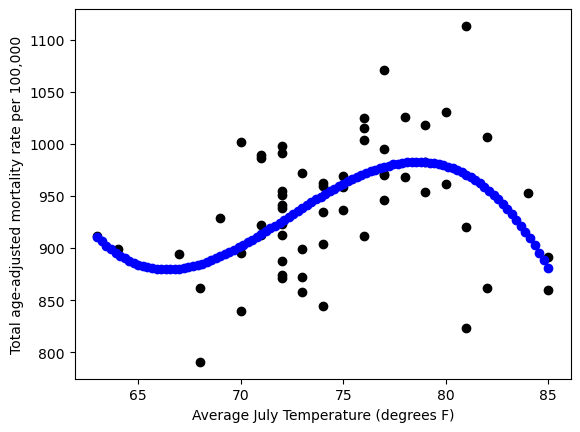

In [5]:
# visualize results
plt.scatter(X, y, color='k')
plt.scatter(X_test, y_pred, color='b')
plt.xlabel('Average July Temperature (degrees F)')
plt.ylabel('Total age-adjusted mortality rate per 100,000')

In [ ]:
def polynomial_regression(X_test, y_test, p, training_data=X):
    poly = PolynomialFeatures(degree=p) #define degree
    X_poly = poly.fit_transform(X.reshape(-1, 1)) #fit to data, then tranform it

    # Fit Linear Regression on the polynomial features
    poly_reg_model = LinearRegression() #create a model
    poly_reg_model.fit(X_poly, y) #fit the model to the transformed features

    # make predictions for provided X_pred
    # X_pred = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    X_pred_poly = poly.transform(X_test.reshape(-1, 1))
    y_pred = poly_reg_model.predict(X_pred_poly)

    # calculate MSE
    mse = np.sum((y_test-y_pred)**2)/len(y_pred)
    
    return y_pred, mse

In [7]:
np.random.seed(0)  # fixed seed for reproducibility
indices = np.random.permutation(len(X)) #shuffle data
half = len(X) // 2

train_idx = indices[:half]
val_idx   = indices[half:]

X_training = X[train_idx]
X_validation = X[val_idx]
y_training = y[train_idx]
y_validation = y[val_idx]

mse_training = np.zeros(4)
mse_validation = np.zeros(4)

for i, p in enumerate(range(1, 5)):
        y_pred, mse = polynomial_regression(X_training, y_training, p, training_data=X_training)
        mse_training[i] = mse
for i, p in enumerate(range(1, 5)):
        y_pred, mse = polynomial_regression(X_validation, y_validation, p, training_data=X_training)
        mse_validation[i] = mse

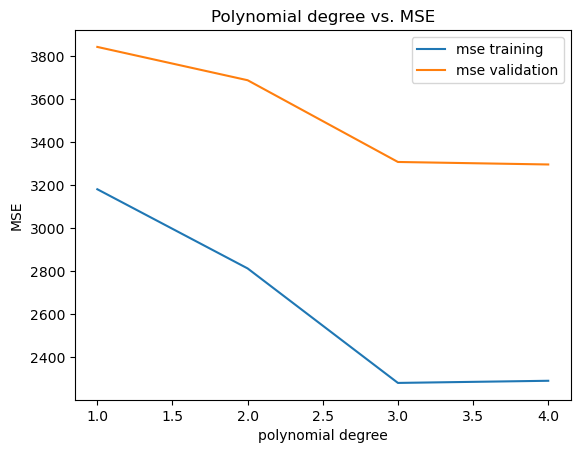

In [8]:
plt.plot(np.arange(1,5,1), mse_training, label=f'mse training')
plt.plot(np.arange(1,5,1), mse_validation, label=f'mse validation')
plt.legend()
plt.xlabel('polynomial degree')
plt.ylabel('MSE')
plt.title('Polynomial degree vs. MSE')
plt.show()

Judging from the graph, a degree 4 of polynomial would be recommended to have the smallest variance of new predictions.

In [9]:
# repeat procedure 10 times with other random seeds
X_training_sets = np.zeros((10, 30))
X_validation_sets = np.zeros((10, 30))
y_training_sets = np.zeros((10, 30))
y_validation_sets = np.zeros((10,30))

for i in range(10):
    np.random.seed(i)  # fixed seed for reproducibility
    indices = np.random.permutation(len(X)) #shuffle data
    half = len(X) // 2

    train_idx = indices[:half]
    val_idx = indices[half:]

    X_training_sets[i] = X[train_idx]
    X_validation_sets[i] = X[val_idx]
    y_training_sets[i] = y[train_idx]
    y_validation_sets[i] = y[val_idx]

In [10]:
# calculate mse for all 10 random seeds
mse_training_sets = np.zeros((10, 4))
mse_validation_sets = np.zeros((10, 4))

for set_idx in range(10):
    for i, p in enumerate(range(1, 5)):
        y_pred, mse = polynomial_regression(X_training_sets[set_idx], y_training_sets[set_idx], p, training_data=X_training_sets[set_idx])
        mse_training_sets[set_idx][i] = mse

for set_idx in range(10):
    for i, p in enumerate(range(1, 5)):
        y_pred, mse = polynomial_regression(X_validation_sets[set_idx], y_validation_sets[set_idx], p, training_data=X_training_sets[set_idx])
        mse_validation_sets[set_idx][i] = mse


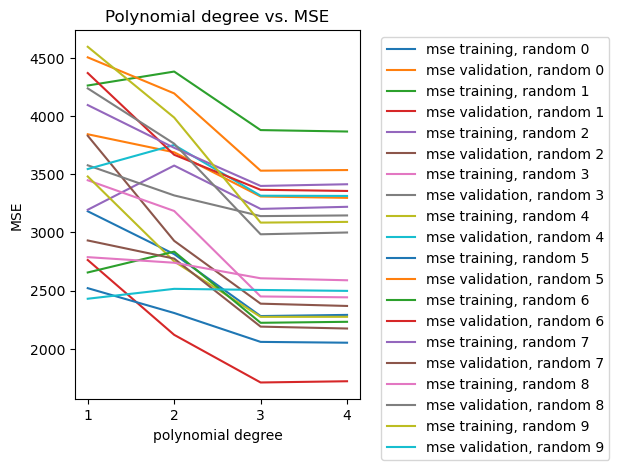

In [11]:
# plot results
for i in range(10):
    plt.plot(np.arange(1,5,1), mse_training_sets[i], label=f'mse training, random {i}')
    plt.plot(np.arange(1,5,1), mse_validation_sets[i], label=f'mse validation, random {i}')

plt.xlabel('polynomial degree')
plt.ylabel('MSE')
plt.title('Polynomial degree vs. MSE')

# move legend to the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()  # adjust layout so labels/legend fit
plt.show()


There are variations of the MSE throught the different seeds. The overall relationship, higher degree polynomial decreases the MSE, stays the same throughout all the different seeds.

In [35]:
fold_size = len(X) // 3
indices = np.arange(len(X))
folds_indices = []
mse_k_folds = np.zeros(3)
for i in range(3):
        test_indices = indices[i * fold_size: (i + 1) * fold_size]
        train_indices = np.concatenate([indices[:i * fold_size], indices[(i + 1) * fold_size:]])
        folds_indices.append((train_indices, test_indices))

for (train_indices, test_indices), idx in zip(folds_indices, range(3)):
    X_train, y_train = X[train_indices], y[train_indices]
    X_test, y_test = X[test_indices], y[test_indices]

    y_pred, mse = polynomial_regression(X_train, y_train, p=2, training_data=X_train)
    mse_k_folds[idx] = mse

In [37]:
# repeat 10 times
mse_k_folds_10 = np.zeros((10, 3))

for seed_idx, ii in enumerate(np.arange(11, 21, 1)):   # Seeds 11 bis 21
    np.random.seed(ii)  # fixed seed for reproducibility
    indices = np.random.permutation(len(X))  # shuffle data
    fold_size = len(X) // 3

    folds_indices = []
    for i in range(3):
        test_indices = indices[i * fold_size: (i + 1) * fold_size]
        train_indices = np.concatenate([indices[:i * fold_size], indices[(i + 1) * fold_size:]])
        folds_indices.append((train_indices, test_indices))

    for (train_indices, test_indices), idx in zip(folds_indices, range(3)):
        X_train, y_train = X[train_indices], y[train_indices]
        X_test, y_test = X[test_indices], y[test_indices]

        y_pred, mse = polynomial_regression(X_train, y_train, p=2, training_data=X_train)
        mse_k_folds_10[seed_idx, idx] = mse


Text(0, 0.5, 'MSE_k')

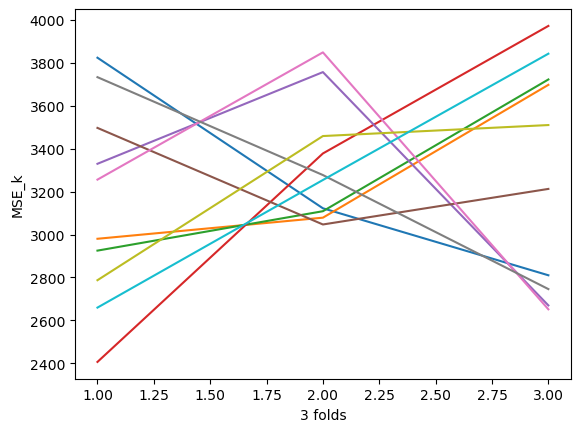

In [60]:
for i in range(10):
    plt.plot(np.arange(1,4,1), mse_k_folds_10[i])
plt.xlabel('3 folds')
plt.ylabel(r'MSE_k')

In [52]:
# average K estimates
mse_folds_10 = mse_k_folds_10.mean(axis=1)
mse_folds_10

array([3251.60510524, 3251.60510524, 3251.60510524, 3251.60510524,
       3251.60510524, 3251.60510524, 3251.60510524, 3251.60510524,
       3251.60510524, 3251.60510524])

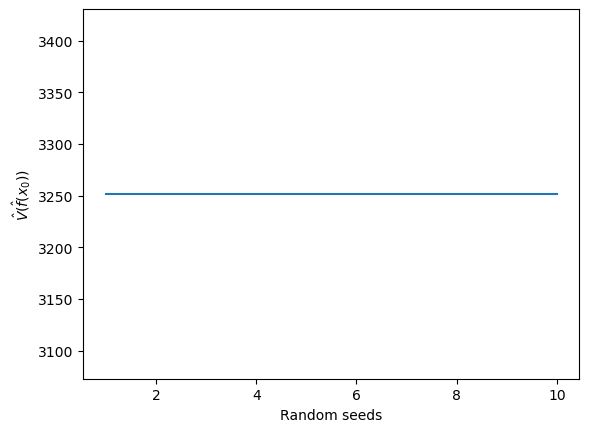

In [128]:
# plot MSE with 10 different random seeds
plt.plot(np.arange(1,11,1), mse_folds_10)
plt.xlabel('Random seeds') 
plt.ylabel(r'$\hat{V}(\hat{f}(x_0))$')
plt.show()

When calculating $\hat{V}(\hat{f}(x_0))$ one gets the same result for all 10 random seeds. However when looking at $MSE_k$ the values throughout the different seeds vary. Due to the k-folding method, we use the whole dataset, divide it into three parts and take two parts as training and one part as testing. Then we use other two parts for training, etc. This is done until all combinations are achieved. In the end when we average $MSE_k$ from the divided dataset and calculate $\hat{V}(\hat{f}(x_0))$, which yields the same values no matter how we divided the data originally, as we are always using the whole dataset for training and testing.

In [ ]:
bird_count = pd.read_csv('../Ex2/bird_count.csv')
x = bird_count['yr'].values
y = bird_count['count'].values

In [ ]:
# bootstrap resampling
#1) if your dataset has 5 entries, take 5 random entries (doubles could also occur)
#2) calculate some metric
#3) store calculation
#4) repeat

c:\Users\rissb\OneDrive\Dokumente\Master_Lund\3_Semester\BERN02\BERN02_Ex_SL\Ex4\possion_reg_ex_func.py:10: RuntimeWarning: overflow encountered in exp
  return np.sum(-np.exp(beta[0]+beta[1]*x) + y*(beta[0]+beta[1]*x) - gammaln(y+1))
c:\Users\rissb\mambaforge\envs\sciproo\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
c:\Users\rissb\OneDrive\Dokumente\Master_Lund\3_Semester\BERN02\BERN02_Ex_SL\Ex4\possion_reg_ex_func.py:10: RuntimeWarning: overflow encountered in exp
  return np.sum(-np.exp(beta[0]+beta[1]*x) + y*(beta[0]+beta[1]*x) - gammaln(y+1))
c:\Users\rissb\OneDrive\Dokumente\Master_Lund\3_Semester\BERN02\BERN02_Ex_SL\Ex4\possion_reg_ex_func.py:10: RuntimeWarning: overflow encountered in exp
  return np.sum(-np.exp(beta[0]+beta[1]*x) + y*(beta[0]+beta[1]*x) - gammaln(y+1))
c:\Users\rissb\mambaforge\envs\sciproo\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: inva

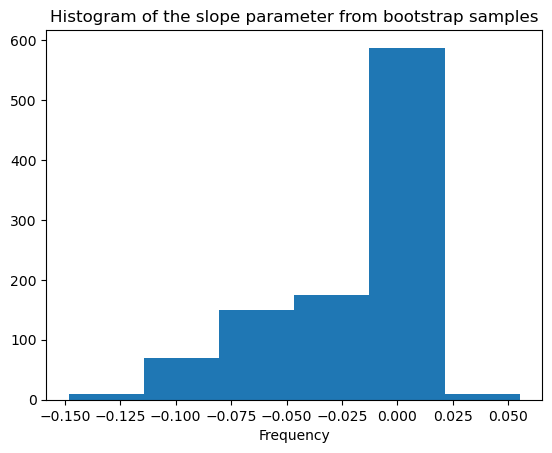

In [124]:
samples = 1000
beta_1_samples = np.zeros(samples)
for i in range(samples):
    #np.random.seed(i)  # fixed seed for reproducibility

    indices = np.random.randint(0, len(x), size=len(x))
    b_x = x[indices]
    b_y = y[indices]

    beta_0 = np.array([np.log(np.mean(y)), 0])
    # Maximum liklihood estimation
    res = minimize(ps_func.neg_likelihood_func, beta_0, args=(b_x, b_y))
    #save beta1
    beta_1_samples[i] = res.x[1]

plt.hist(beta_1_samples, bins=6)
plt.xlabel(r'$\beta_1$')
plt.xlabel('Frequency')
plt.title('Histogram of the slope parameter from bootstrap samples')
plt.show()


In [126]:
# standard deviation of the bootstrap sample of the slope parameter
std_beta_1 = np.std(beta_1_samples)
print(f'The standard deviation of the bootstrap sample of the slope parameter is {round(std_beta_1,5)}')

The standard deviation of the bootstrap sample of the slope parameter is 0.03256
